# Analiza zbioru danych

Co jest w danych, zanim cokolwiek wytrenujemy. Trzy podzbiory naturalne plus Eterna, obie pule
po odsianiu redundancji **natywnym** `cd-hit-est`.

Eterna jest wszedzie ograniczona do **<= 50 nt** — limit nakladany raz, w `src/cdhit.py`, wiec
wszystko ponizej dziedziczy go automatycznie. Nigdzie nie analizujemy calej Eterny.

Caly kod rysujacy jest w tym notatniku — mozna go edytowac na miejscu.


In [7]:
import sys
from collections import Counter
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from src.dataset import motyw_pozycji, parse_pairs, BASES, MOTYWY
from src.prepare import wczytaj, wczytaj_eterna
from src.split import wczytaj_split

# --- wspolny styl wykresow -------------------------------------------------
# Paleta sprawdzona pod katem separacji przy protanopii i deuteranopii oraz kontrastu wobec tla.
C1, C2, C3, C4 = "#0E6B60", "#9C5518", "#6B4E9C", "#8A9896"
INK, INK2, SIATKA = "#14201E", "#4C5C59", "#DCE4E2"
plt.rcParams["figure.dpi"] = 120


def styl(ax, tytul="", ylab="", xlab=""):
    """Wspolne ustawienia osi: bez ramki, siatka pozioma, stonowane opisy."""
    ax.set_facecolor("none")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(SIATKA)
    ax.tick_params(colors=INK2, labelsize=9)
    ax.grid(axis="y", color=SIATKA, lw=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    if tytul:
        ax.set_title(tytul, color=INK, fontsize=11, loc="left", pad=12)
    ax.set_ylabel(ylab, color=INK2, fontsize=9)
    ax.set_xlabel(xlab, color=INK2, fontsize=9)


def sklad_motywy(structs, seqs):
    """Zliczenia A/C/G/U w kazdym motywie strukturalnym, po wszystkich sekwencjach."""
    c = {m: Counter() for m in MOTYWY}
    for st, sq in zip(structs, seqs):
        for m, b in zip(motyw_pozycji(st), sq):
            if m:
                c[m][b] += 1
    return c


def typy_par(structs, seqs):
    """Zliczenia typow par G:C / A:U / G:U."""
    t = Counter()
    grupy = {"G:C": {"GC", "CG"}, "A:U": {"AU", "UA"}, "G:U": {"GU", "UG"}}
    for st, sq in zip(structs, seqs):
        for i, j in parse_pairs(st):
            p = sq[i] + sq[j]
            for k, g in grupy.items():
                if p in g:
                    t[k] += 1
    return t


In [8]:
df = wczytaj()
spl = wczytaj_split("rodzinowy")
czesci = {z: df.iloc[spl[z]] for z in ("train", "val", "test")}
eterna = wczytaj_eterna()
ZBIORY = ["train", "val", "test"]

print(f"zbior roboczy: {len(df)} struktur, {df.family.nunique()} rodzin")
for z, d in czesci.items():
    L = d.secondary_structure.str.len()
    print(f"  {z:6} {len(d):5}  rodzin {d.family.nunique():4}  mediana {int(L.median()):4} nt")
L = eterna.secondary_structure.str.len()
print(f"Eterna <= 50 nt: {len(eterna)} zagadek, dlugosci {L.min()}-{L.max()}")

zbior roboczy: 3699 struktur, 340 rodzin
  train   2220  rodzin  110  mediana   78 nt
  val      740  rodzin  117  mediana   89 nt
  test     739  rodzin  113  mediana   92 nt
Eterna <= 50 nt: 11 zagadek, dlugosci 16-45


## 1. Dlugosc struktur

Kubelki 0-50, 51-100 i 101-200 nt to te same, w ktorych raportujemy wyniki. Kubelek najkrotszy jest
bardzo maly — to ograniczenie, ktore trzeba miec z tylu glowy przy kazdym wniosku o krotkich
strukturach.

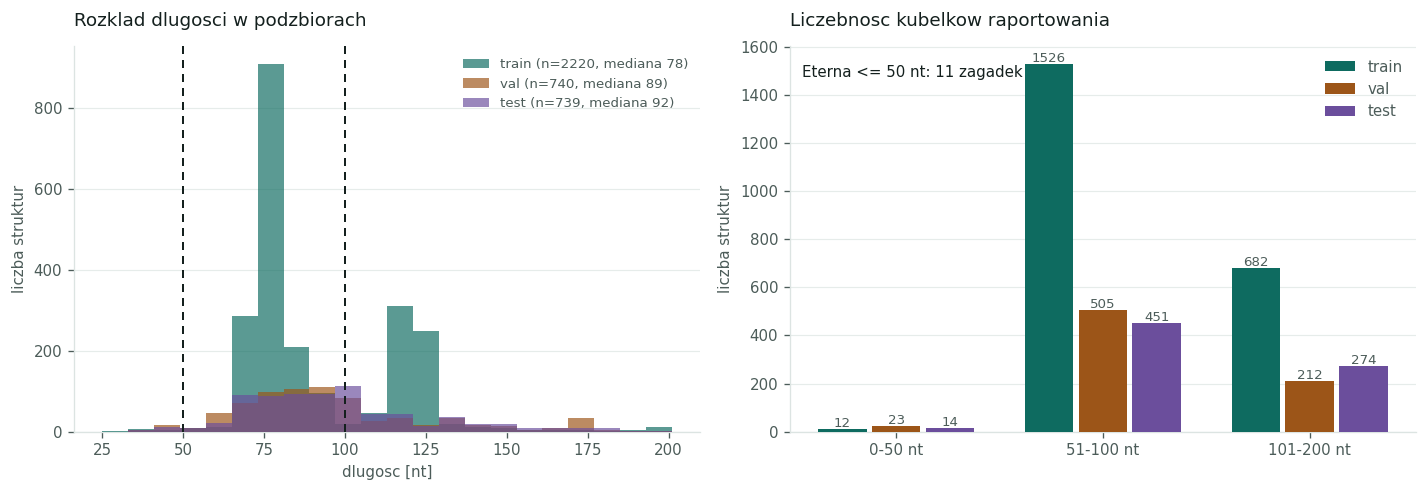

In [9]:
KUBELKI = [(0, 50), (51, 100), (101, 200)]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))

for z, kol in zip(ZBIORY, (C1, C2, C3)):
    L = czesci[z].secondary_structure.str.len()
    axs[0].hist(L, bins=np.arange(25, 205, 8), alpha=0.68, color=kol, zorder=3,
                label=f"{z} (n={len(L)}, mediana {int(L.median())})")
for gr in (50, 100):
    axs[0].axvline(gr, color=INK, lw=1.2, ls=(0, (4, 3)), zorder=4)
styl(axs[0], "Rozklad dlugosci w podzbiorach", "liczba struktur", "dlugosc [nt]")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)

x = np.arange(len(KUBELKI))
w = 0.26
for k, (z, kol) in enumerate(zip(ZBIORY, (C1, C2, C3))):
    L = czesci[z].secondary_structure.str.len()
    v = [int(((L >= lo) & (L <= hi)).sum()) for lo, hi in KUBELKI]
    b = axs[1].bar(x + (k - 1) * w, v, w * 0.9, color=kol, label=z, zorder=3)
    for r, vv in zip(b, v):
        axs[1].text(r.get_x() + r.get_width() / 2, vv + 8, str(vv),
                    ha="center", fontsize=8, color=INK2)
axs[1].text(0.02, 0.92, f"Eterna <= 50 nt: {len(eterna)} zagadek",
            transform=axs[1].transAxes, fontsize=9, color=INK)
axs[1].set_xticks(x)
axs[1].set_xticklabels([f"{a}-{b} nt" for a, b in KUBELKI], fontsize=9)
styl(axs[1], "Liczebnosc kubelkow raportowania", "liczba struktur")
axs[1].legend(frameon=False, fontsize=9, labelcolor=INK2)
fig.tight_layout()

## 2. Rodziny Rfam

Podzial jest RODZINOWY: kazda rodzina trafia do dokladnie jednego podzbioru, wiec test sklada sie
z rodzin, ktorych model nie widzial ani razu.

Procenty to **udzial w calym podzbiorze**, a slupki sumuja sie do 100%. Osobno pokazujemy tylko
rodziny stanowiace **co najmniej 1%** zbioru (najwyzej szesc); cala reszta trafia do slupka
zbiorczego "pozostale". Bez tego train mial dwa sensowne slupki i cztery pokazujace 0%.

train  pokazane osobno: 2 rodzin =  91.2%,  pozostale 108 rodzin =   8.8%
val    pokazane osobno: 6 rodzin =  40.9%,  pozostale 111 rodzin =  59.1%
test   pokazane osobno: 6 rodzin =  36.1%,  pozostale 107 rodzin =  63.9%


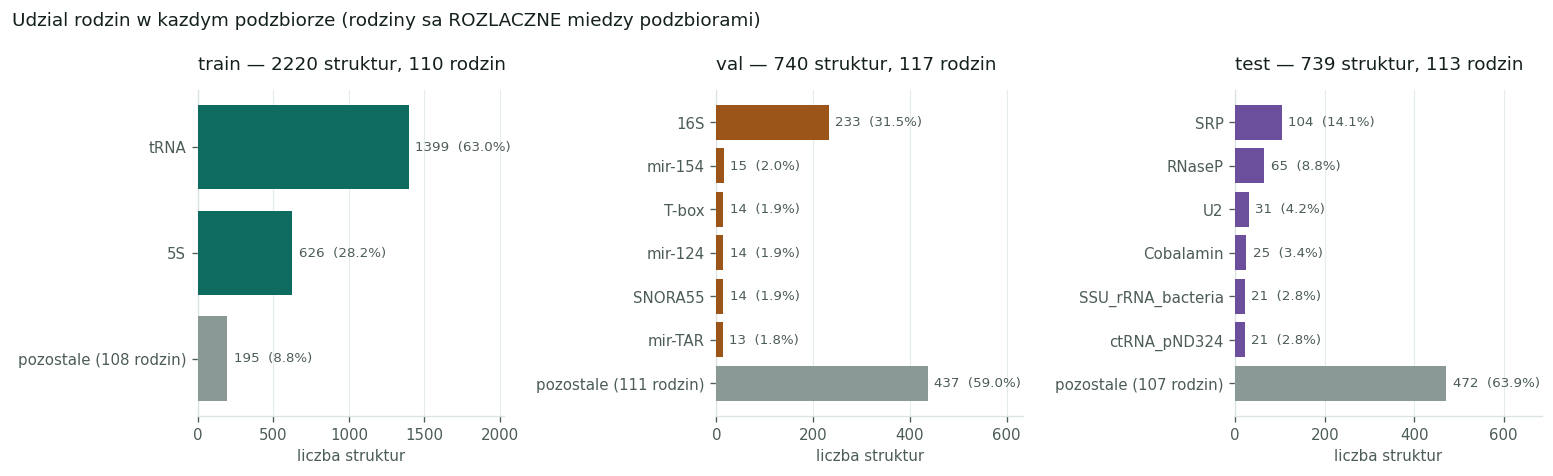

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4.0))
PROG = 0.01          # rodziny ponizej 1% zbioru trafiaja do slupka zbiorczego

for ax, z, kol in zip(axs, ZBIORY, (C1, C2, C3)):
    d = czesci[z]
    vc = d.family.value_counts()
    duze = vc[vc / len(d) >= PROG].head(6)          # tylko rodziny o wyraznym udziale
    reszta = len(d) - duze.sum()
    n_reszta = d.family.nunique() - len(duze)

    etykiety = [f"pozostale ({n_reszta} rodzin)"] + list(duze.index)[::-1]
    wartosci = [reszta] + list(duze.values)[::-1]
    kolory = [C4] + [kol] * len(duze)

    ax.barh(range(len(wartosci)), wartosci, color=kolory, zorder=3)
    procenty = [v / len(d) * 100 for v in wartosci]
    procenty_rounded = [round(p, 1) for p in procenty]
    # Skompensuj największą wartość aby suma była dokładnie 100%
    idx_max = procenty.index(max(procenty))
    procenty_rounded[idx_max] += 100.0 - sum(procenty_rounded)
    for i, (v, p) in enumerate(zip(wartosci, procenty_rounded)):
        ax.text(v + max(wartosci) * 0.03, i, f"{v}  ({p:.1f}%)",
                va="center", fontsize=8, color=INK2)
    ax.set_yticks(range(len(etykiety)))
    ax.set_yticklabels(etykiety, fontsize=8)
    ax.set_xlim(0, max(wartosci) * 1.45)
    styl(ax, f"{z} — {len(d)} struktur, {d.family.nunique()} rodzin", "", "liczba struktur")
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", color=SIATKA, lw=0.7, alpha=0.7)
fig.suptitle("Udzial rodzin w kazdym podzbiorze (rodziny sa ROZLACZNE miedzy podzbiorami)",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

for z in ZBIORY:
    d = czesci[z]
    vc = d.family.value_counts()
    duze = vc[vc / len(d) >= 0.01].head(6)
    print(f"{z:6} pokazane osobno: {len(duze)} rodzin = {duze.sum() / len(d) * 100:5.1f}%,  "
          f"pozostale {d.family.nunique() - len(duze)} rodzin = "
          f"{(len(d) - duze.sum()) / len(d) * 100:5.1f}%")

## 3. Sklad zasad wg motywu strukturalnego

Kazda pozycja dostaje etykiete motywu: wnetrze helisy, koniec helisy, petla spinki, wybrzuszenie,
multipetla albo region zewnetrzny. Potem liczymy udzialy A/C/G/U osobno w kazdym motywie.

Warto porownac podzbiory naturalne z Eterna — **rozwiazania ludzi celowo odbiegaja od skladu
naturalnego**, bo sa projektowane pod jednoznaczne zwijanie, a nie pod funkcje biologiczna.

Uwaga: Eterna to tylko 11 zagadek, wiec jej slupki sa bardzo szumne.

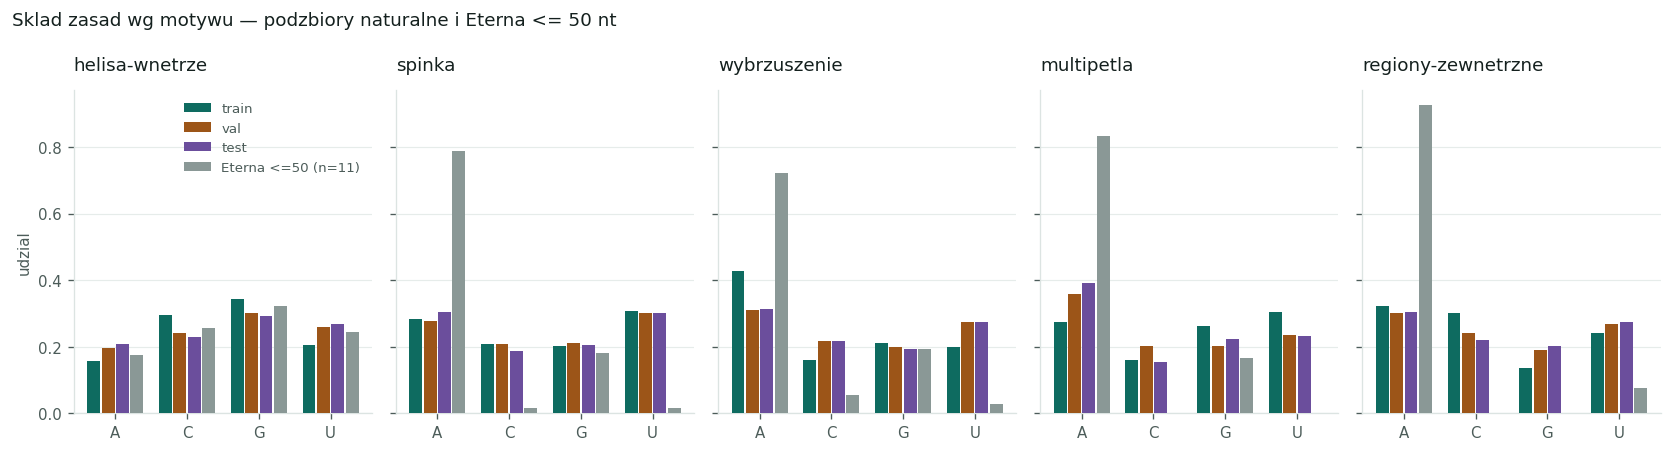

In [11]:
zrodla = [(z, czesci[z]) for z in ZBIORY] + [(f"Eterna <=50 (n={len(eterna)})", eterna)]
kolory_z = [C1, C2, C3, C4]
pokaz = ["helisa-wnetrze", "spinka", "wybrzuszenie", "multipetla", "regiony-zewnetrzne"]

fig, axs = plt.subplots(1, len(pokaz), figsize=(14, 3.8), sharey=True)
x = np.arange(4)
w = 0.8 / len(zrodla)
for ax, m in zip(axs, pokaz):
    for k, (nz, d) in enumerate(zrodla):
        c = sklad_motywy(d.secondary_structure, d.sequence)[m]
        t = sum(c.values()) or 1
        ax.bar(x + (k - (len(zrodla) - 1) / 2) * w, [c[b] / t for b in BASES], w * 0.9,
               color=kolory_z[k], label=nz if m == pokaz[0] else None, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(BASES, fontsize=9)
    styl(ax, m, "udzial" if m == pokaz[0] else "")
axs[0].legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.suptitle("Sklad zasad wg motywu — podzbiory naturalne i Eterna <= 50 nt",
             color=INK, fontsize=11, x=0.008, ha="left")
fig.tight_layout()

## 4. Typy par

Trzy typy par kanonicznych. Pary chwiejne G:U sa slabsze energetycznie, ale w naturze wystepuja
regularnie. To jest wielkosc, wokol ktorej toczy sie caly spor o degeneracje w wynikach: model dazacy
wylacznie do stabilnosci zastepuje wszystko parami G:C.

train                 G:C 0.598  A:U 0.299  G:U 0.103
val                   G:C 0.500  A:U 0.364  G:U 0.135
test                  G:C 0.471  A:U 0.390  G:U 0.139
Eterna <=50 (n=11)    G:C 0.767  A:U 0.167  G:U 0.067


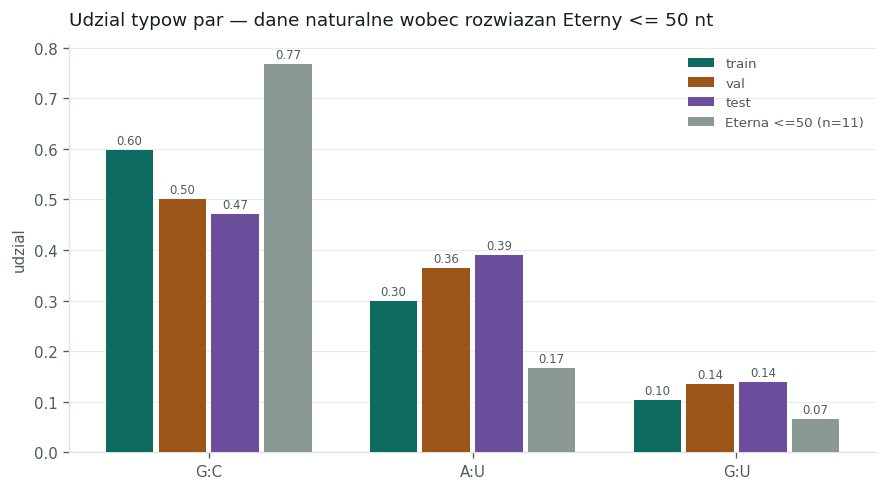

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
x = np.arange(3)
w = 0.8 / len(zrodla)
for k, (nz, d) in enumerate(zrodla):
    t = typy_par(d.secondary_structure, d.sequence)
    tot = sum(t.values()) or 1
    v = [t[g] / tot for g in ("G:C", "A:U", "G:U")]
    b = ax.bar(x + (k - (len(zrodla) - 1) / 2) * w, v, w * 0.9, color=kolory_z[k], label=nz, zorder=3)
    for r, vv in zip(b, v):
        ax.text(r.get_x() + r.get_width() / 2, vv + 0.012, f"{vv:.2f}",
                ha="center", fontsize=7, color=INK2)
ax.set_xticks(x)
ax.set_xticklabels(["G:C", "A:U", "G:U"], fontsize=10)
styl(ax, "Udzial typow par — dane naturalne wobec rozwiazan Eterny <= 50 nt", "udzial")
ax.legend(frameon=False, fontsize=8, labelcolor=INK2)
fig.tight_layout()

for nz, d in zrodla:
    t = typy_par(d.secondary_structure, d.sequence)
    tot = sum(t.values()) or 1
    print(f"{nz:22}" + "  ".join(f"{k} {t[k] / tot:.3f}" for k in ("G:C", "A:U", "G:U")))